In [3]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit

In [13]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(discharge_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(discharge_directory, "ocv_soc_dict.csv")

output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled (with SoC).csv")

In [90]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [91]:
compiled_df = pd.read_csv(compiled_file_name)

In [92]:
compiled_df.tail()

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage
11362389,1.106171e+07,184.361849,38670.0,15.163809,38587.0,14.943919,23465.0,21.999711
11362390,1.106171e+07,184.361864,38669.0,15.161158,38587.0,14.943919,23465.0,21.998773
11362391,1.106171e+07,184.361880,38669.0,15.161158,38614.0,15.015427,23465.0,21.998773
11362392,1.106171e+07,184.361896,38669.0,15.161158,38614.0,15.015427,23465.0,21.997836
11362393,1.106171e+07,184.361911,38652.0,15.116105,38614.0,15.015427,23464.0,21.999711


In [93]:
if (str(compiled_df['Calibrated Current 2'].iloc[0]) != 'nan'):
    
    average_current = ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2 + 
                   ((compiled_df['Calibrated Current 1'] + compiled_df['Calibrated Current 2']) / 2).shift(1)) / 2
else:
    print("Calibrated Current 2 is NaN, using Calibrated Current 1 only for charge calculation.")
    average_current = compiled_df['Calibrated Current 1']
print(str(compiled_df['Calibrated Current 2'].iloc[0]) + ", " + str(type(compiled_df['Calibrated Current 2'].iloc[0])))
average_current[average_current < 0] = 0
average_current = average_current.fillna(0)

delta_time = compiled_df['Translated Time'].diff() / 1000   # Convert ms to seconds
delta_time = delta_time.fillna(0)

compiled_df['Charge Change'] = average_current * delta_time

sensor_draw_estimate = 0.081

total_charge = compiled_df['Charge Change'].sum()
total_Ah = (total_charge / 3600) - sensor_draw_estimate

print(f"Total Charge: {total_charge:.4f} Coulombs")
print(f"Total Ah: {total_Ah:.4f} Ah")

-0.0934846671138361, <class 'numpy.float64'>
Total Charge: 143785.1685 Coulombs
Total Ah: 39.8593 Ah


In [94]:
compiled_df['SoC'] = compiled_df['Charge Change'].cumsum()
compiled_df['SoC'] = (total_charge - compiled_df['SoC']) / total_charge * 100
compiled_df.head()

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage,Charge Change,SoC
0,0.000,0.000000,32755.0,-0.031158,32730.0,-0.093485,55913.0,52.419237,0.0,100.0
1,0.942,0.000016,32746.0,-0.053594,32722.5,-0.112186,55913.5,52.420175,0.0,100.0
2,1.880,0.000031,32737.0,-0.076032,32722.0,-0.113433,55914.0,52.419237,0.0,100.0
3,2.819,0.000047,32755.0,-0.031158,32722.0,-0.113433,55914.0,52.420175,0.0,100.0
4,3.757,0.000063,32737.0,-0.076032,32722.0,-0.113433,55914.0,52.420175,0.0,100.0


In [95]:
before_close = points_of_interest['before_close']
before_open = points_of_interest['before_open']
before_close['SoC'] = []
before_open['SoC'] = []
for index in before_close['index']:
    before_close['SoC'].append(compiled_df.at[index, 'SoC'])

for index in before_open['index']:
    before_open['SoC'].append(compiled_df.at[index, 'SoC'])

print(f"Before Close: {json.dumps(before_close)}")
print(f"Before Open: {json.dumps(before_open)}")
print(len(before_close['SoC']), len(before_close['voltage']))
print(len(before_open['SoC']), len(before_open['voltage']))

Before Close: {"index": [1480000, 2671045, 4239708, 5523407, 6945422, 8190944, 9440165], "time": [23.9086519, 43.66643954999999, 68.95378443000001, 89.75069793250005, 112.76274617000001, 132.93641707333336, 153.0244092233334], "voltage": [52.36579903868163, 52.635896910048075, 52.32712657358663, 52.22109370565346, 52.188561959258415, 51.905010757610434, 51.23853183794919], "SoC": [84.85509708837074, 72.16322333371197, 61.569755525537595, 49.81162925658849, 38.440125754695394, 27.089915337392302, 15.868771756896077]}
Before Open: {"index": [784146, 2092393, 3596300, 4875703, 6146751, 7556718, 8810603], "time": [12.6062807, 34.32035291666666, 58.53231191666667, 79.33039983083337, 99.81197282333336, 122.70627217333337, 142.9380094], "voltage": [50.26857953765164, 50.57847489127948, 50.50108308537423, 50.39856589608606, 50.209703639276725, 49.95263721675441, 49.36500325017166], "SoC": [84.87648064797088, 72.17216563767099, 62.06764176270517, 49.819285775247025, 38.44773414435644, 27.097436

C:\Users\Kor\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


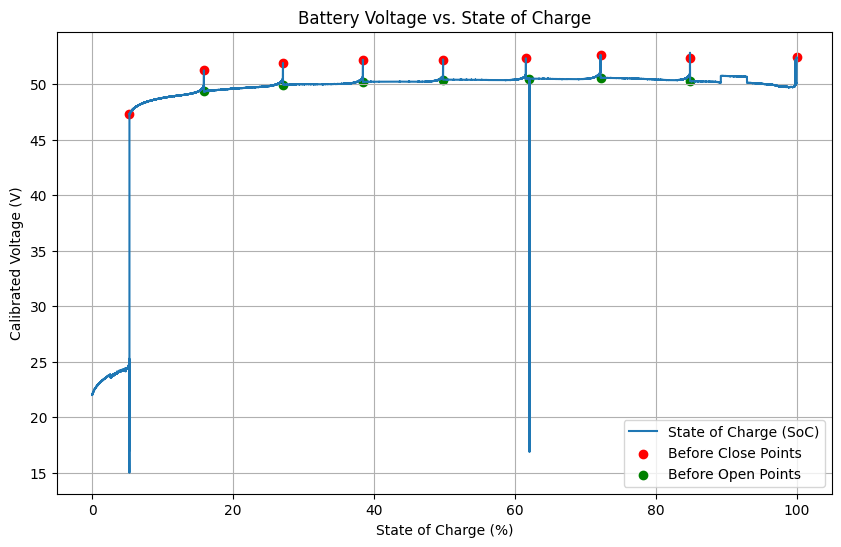

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(compiled_df['SoC'].iloc[:12694795], compiled_df['Calibrated Voltage'].iloc[:12694795], label='State of Charge (SoC)')
plt.scatter(before_close['SoC'], before_close['voltage'], color='red', label='Before Close Points')
plt.scatter(before_open['SoC'], before_open['voltage'], color='green', label='Before Open Points')
plt.xlabel('State of Charge (%)')
plt.ylabel('Calibrated Voltage (V)')
plt.title('Battery Voltage vs. State of Charge')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(len(compiled_df))

11362394


In [96]:
# As the final OCV at SoC = 0
idx = -1

if before_close['index'][-1] != len(compiled_df) - 1:
    while compiled_df['Calibrated Voltage'].iloc[idx] < 40:
        idx -= 5
    last_point = compiled_df.iloc[idx]
    before_close['SoC'].append(last_point['SoC'])
    before_close['voltage'].append(last_point['Calibrated Voltage'])
    before_close['time'].append(last_point['Translated Time (minutes)'])
    before_close['index'].append(len(compiled_df) - idx)
    
    print(f"Added last point to before_close: SoC={last_point['SoC']}, Voltage={last_point['Calibrated Voltage']}, Index={len(compiled_df) - 1}")

Added last point to before_close: SoC=5.296208341644136, Voltage=47.3182220187686, Index=11362393


In [97]:
# Add the first point that is less than 100 soc to allow fitting for log later
idx = 0
if before_close['index'][0] != 0:
    while compiled_df['SoC'].iloc[idx] >= 100:
        idx += 5
    first_point = compiled_df.iloc[idx]
    
    before_close['SoC'].insert(0, first_point['SoC'])
    before_close['voltage'].insert(0, compiled_df['Calibrated Voltage'].iloc[0]) # but use the highest voltage at idx 0
    before_close['time'].insert(0, first_point['Translated Time (minutes)'])
    before_close['index'].insert(0, idx)
    
    print(f"Added first point to before_close: SoC={first_point['SoC']}, Voltage={first_point['Calibrated Voltage']}, Index={idx}")

Added first point to before_close: SoC=99.9999870649914, Voltage=50.4148317692836, Index=4360


In [98]:
print(before_close)
print(before_open)

{'index': [4360, 1480000, 2671045, 4239708, 5523407, 6945422, 8190944, 9440165, 12694795], 'time': [np.float64(0.0683787999999999), 23.9086519, 43.66643954999999, 68.95378443000001, 89.75069793250005, 112.76274617000001, 132.93641707333336, 153.0244092233334, np.float64(162.5818921000001)], 'voltage': [np.float64(52.4192373540856), 52.36579903868163, 52.635896910048075, 52.32712657358663, 52.22109370565346, 52.188561959258415, 51.905010757610434, 51.23853183794919, np.float64(47.3182220187686)], 'SoC': [np.float64(99.9999870649914), np.float64(84.85509708837074), np.float64(72.16322333371197), np.float64(61.569755525537595), np.float64(49.81162925658849), np.float64(38.440125754695394), np.float64(27.089915337392302), np.float64(15.868771756896077), np.float64(5.296208341644136)]}
{'index': [784146, 2092393, 3596300, 4875703, 6146751, 7556718, 8810603], 'time': [12.6062807, 34.32035291666666, 58.53231191666667, 79.33039983083337, 99.81197282333336, 122.70627217333337, 142.9380094], 'vo

In [99]:
ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)
parameters, covariance = curve_fit(ocv_model, before_close['SoC'], before_close['voltage'], p0=[0.0, 0.01, -0.0001, 0.1, 0.1])
a, b, c, d, e = parameters
print(f"Fitted OCV model parameters: a={a:.5f}, b={b:.5f}, c={c:.5f}, d={d:.5f}, e={e:.5f}")

Fitted OCV model parameters: a=39.77746, b=-0.19218, c=0.00092, d=5.02765, e=0.04341


In [100]:
def filter_df(soc, ocv, index_to_rm=[]):
    new_soc = []
    new_ocv = []
    for i in range(len(soc)):
        if i not in index_to_rm:
            new_soc.append(soc[i])
            new_ocv.append(ocv[i])
    return new_soc, new_ocv

In [114]:
before_close['SoC'][-1] = np.float64(0.01)
before_close['voltage'][-1] = np.float64(46.7)
print(before_close['voltage'])

[np.float64(52.4192373540856), 52.36579903868163, 52.635896910048075, 52.32712657358663, 52.22109370565346, 52.188561959258415, 51.905010757610434, 51.23853183794919, np.float64(47.3182220187686), np.float64(46.7)]


In [115]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
print(f"Original SoC: {soc}")
print(f"Original OCV: {ocv}")

Original SoC: [1.00000000e-02 5.29620834e+00 1.58687718e+01 2.70899153e+01
 3.84401258e+01 4.98116293e+01 6.15697555e+01 7.21632233e+01
 8.48550971e+01 9.99999871e+01]
Original OCV: [46.7        47.31822202 51.23853184 51.90501076 52.18856196 52.22109371
 52.32712657 52.63589691 52.36579904 52.41923735]


C:\Users\Kor\AppData\Local\Temp\ipykernel_25296\3450962758.py:1: RuntimeWarning: divide by zero encountered in log
  ocv_model = lambda soc, a, b, c, d, e: a + b * soc + c * soc**2 + d * np.log(soc) + e * np.log(100 - soc)


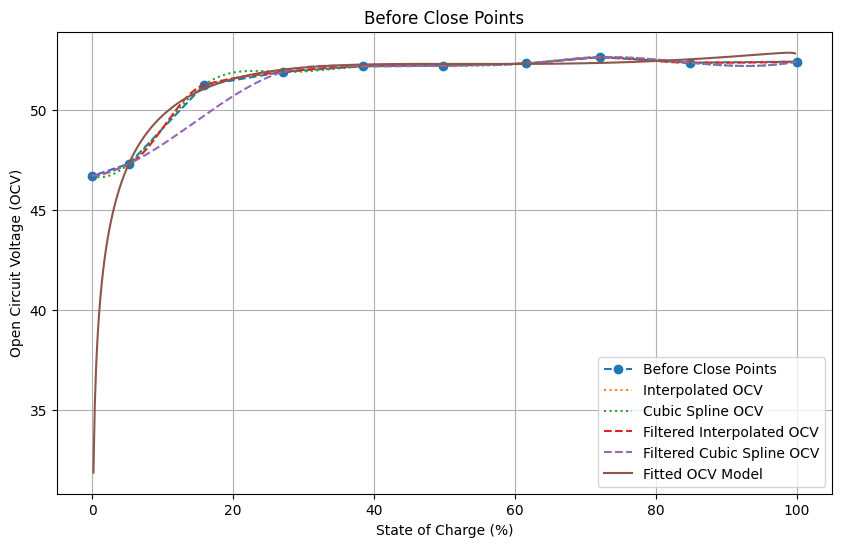

In [116]:
soc = np.flip(np.array(before_close['SoC'].copy()))
ocv = np.flip(np.array(before_close['voltage'].copy()))
""" soc = soc[:-1]
ocv = ocv[:-1]
soc = soc[:-3]
ocv = ocv[:-3] """


soc_smooth = np.linspace(0, 100, 500)

piecewise_cubic_interp = PchipInterpolator(soc, ocv)
piecewise_cubic_spline_ocv_smooth = piecewise_cubic_interp(soc_smooth)

filtered_piecewise_cubic_interp = PchipInterpolator(soc, ocv)
filtered_piecewise_cubic_spline_ocv_smooth = filtered_piecewise_cubic_interp(soc_smooth)

cubic_spline_interp = make_interp_spline(soc, ocv)
cubic_spline_ocv_smooth = cubic_spline_interp(soc_smooth)

filtered_cubic_spline_interp = make_interp_spline(*filter_df(soc, ocv, index_to_rm=[2]))
filtered_cubic_spline_ocv_smooth = filtered_cubic_spline_interp(soc_smooth)

plt.figure(figsize=(10, 6))
plt.plot(before_close['SoC'], before_close['voltage'], label='Before Close Points', linestyle='--', marker='o')
plt.plot(soc_smooth, piecewise_cubic_spline_ocv_smooth, label='Interpolated OCV', linestyle=':')
plt.plot(soc_smooth, cubic_spline_ocv_smooth, label='Cubic Spline OCV', linestyle=':')

plt.plot(soc_smooth, filtered_piecewise_cubic_spline_ocv_smooth, label='Filtered Interpolated OCV', linestyle='--')
plt.plot(soc_smooth, filtered_cubic_spline_ocv_smooth, label='Filtered Cubic Spline OCV', linestyle='--')

plt.plot(soc_smooth, ocv_model(soc_smooth, *parameters), label='Fitted OCV Model', linestyle='-')

plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('Before Close Points')
plt.legend()
plt.grid(True)
plt.show()

In [117]:
# Piecewise Function

print("Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]")
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}:\tx in [{knots[i]}, {knots[i+1]}]")
    print(f"\t\tCoefficients: c0={coef[0][i]}, c1={coef[1][i]}, c2={coef[2][i]}, c3={coef[3][i]}")

Function: f(x) = c0*(x-x_i)^3 + c1*(x-x_i)^2 + c2*(x-x_i) + c3 for x in [x_i, x_{i+1}]
Total number of intervals: 9
Interval 0:	x in [0.01, 5.296208341644136]
		Coefficients: c0=-0.0011977536814397891, c1=0.022338510044358523, c2=0.032334000247653, c3=46.7
Interval 1:	x in [5.296208341644136, 15.868771756896077]
		Coefficients: c0=-0.004208076596082593, c1=0.06366283502507064, c2=0.1680959548161825, c3=47.3182220187686
Interval 2:	x in [15.868771756896077, 27.089915337392302]
		Coefficients: c0=0.00015516979818638413, c1=-0.0056387129751881305, c2=0.10312966761980084, c3=51.23853183794919
Interval 3:	x in [27.089915337392302, 38.440125754695394]
		Coefficients: c0=-7.475746492593356e-05, c1=-5.1576926868205134e-05, c2=0.03519823116411907, c3=51.905010757610434
Interval 4:	x in [38.440125754695394, 49.81162925658849]
		Coefficients: c0=2.8957502305018784e-05, c1=-0.0005292813323906318, c2=0.005135011401673114, c3=52.188561959258415
Interval 5:	x in [49.81162925658849, 61.569755525537595

In [118]:
knots = piecewise_cubic_interp.x
coef = piecewise_cubic_interp.c
intervals = len(coef[0])
print(f"Total number of intervals: {intervals}")
for i in range(intervals):
    print(f"Interval {i}: f(x) = {coef[0][i]} * (x-{knots[i]})**3 + {coef[1][i]} * (x-{knots[i]})**2 + {coef[2][i]} * (x-{knots[i]}) + {coef[3][i]} \n\tfor x in [{knots[i]}, {knots[i+1]}]")
    


Total number of intervals: 9
Interval 0: f(x) = -0.0011977536814397891 * (x-0.01)**3 + 0.022338510044358523 * (x-0.01)**2 + 0.032334000247653 * (x-0.01) + 46.7 
	for x in [0.01, 5.296208341644136]
Interval 1: f(x) = -0.004208076596082593 * (x-5.296208341644136)**3 + 0.06366283502507064 * (x-5.296208341644136)**2 + 0.1680959548161825 * (x-5.296208341644136) + 47.3182220187686 
	for x in [5.296208341644136, 15.868771756896077]
Interval 2: f(x) = 0.00015516979818638413 * (x-15.868771756896077)**3 + -0.0056387129751881305 * (x-15.868771756896077)**2 + 0.10312966761980084 * (x-15.868771756896077) + 51.23853183794919 
	for x in [15.868771756896077, 27.089915337392302]
Interval 3: f(x) = -7.475746492593356e-05 * (x-27.089915337392302)**3 + -5.1576926868205134e-05 * (x-27.089915337392302)**2 + 0.03519823116411907 * (x-27.089915337392302) + 51.905010757610434 
	for x in [27.089915337392302, 38.440125754695394]
Interval 4: f(x) = 2.8957502305018784e-05 * (x-38.440125754695394)**3 + -0.0005292813

In [119]:
# 2 options: Reverse each interval function to get SoC from OCV or a dictionary of OCV to SoC values for each point ~1000 interval.

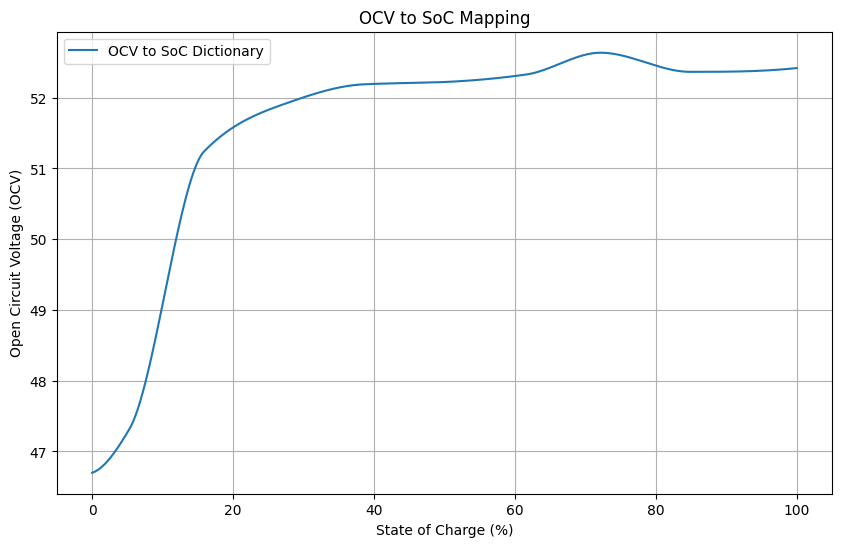

In [120]:
# Option 2: Faster O(1), but takes ~3000kb of data for 3 dp precision. 
# Not suitable for microcontroller but can be used for RPi

factor = 3 # Number of dp
array_interval = factor + 2 # Additional 2 for 0 - 100% SoC
ocv_soc_dict = {}
ocv_intervals = np.linspace(0, 100, 10**array_interval + 1)
for ocv_value in ocv_intervals:
    soc_value = filtered_piecewise_cubic_interp(ocv_value)
    ocv_soc_dict[round(ocv_value, factor+2)] = soc_value.item()

output_df = pd.DataFrame({
    "SoC": list(ocv_soc_dict.keys()),
    "OCV": list(ocv_soc_dict.values())
})

plt.figure(figsize=(10, 6))
plt.plot(output_df['SoC'], output_df['OCV'], label='OCV to SoC Dictionary', linestyle='-')
plt.xlabel('State of Charge (%)')
plt.ylabel('Open Circuit Voltage (OCV)')
plt.title('OCV to SoC Mapping')
plt.legend()
plt.grid(True)
plt.show()

In [121]:
output_df.to_csv(ocv_soc_dict_file_name, index=False)
print(f"Saved OCV to SoC dictionary with {len(ocv_soc_dict)} entries to {ocv_soc_dict_file_name}")
print(f"To use, get the ceiling of voltage reading to {factor} decimal places and look up corresponding SoC value in the dictionary.")

Saved OCV to SoC dictionary with 100001 entries to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\ocv_soc_dict.csv
To use, get the ceiling of voltage reading to 3 decimal places and look up corresponding SoC value in the dictionary.


In [130]:
compiled_df.to_csv(output_file_name, index=False)